In [9]:
# not so intuitive abbreviations:
# DS = Dataset
# .CP = CellPop in use
# .SD = Standard Deviation
# .EE = Everything else
# .SM = Signaling molecules

# Setup

In [10]:
#essential reticulate functions (must run first)
Sys.setenv(RETICULATE_PYTHON="/home/luca/anaconda3/envs/reticulate/bin/python")
library(reticulate)
reticulate::use_python("/home/luca/anaconda3/envs/reticulate/bin/python")
reticulate::use_condaenv("/home/luca/anaconda3/envs/reticulate")
reticulate::py_module_available(module='anndata') #needs to be TRUE
reticulate::import('anndata') #good to make sure this doesn't error

[1] TRUE

Module(anndata)

## Load libraries

In [11]:
pacman::p_load(dplyr, stringr, data.table, tidyr,plyr,logr,
               pheatmap, colorRamps, gridExtra, ggplot2, ggrepel, RColorBrewer, ComplexHeatmap,
               Rmagic, phateR, parallel,
               Seurat, harmony)

## Working Directories and Options

In [12]:
Combine.Seurat = "/nfs/lab/projects/CellCrosstalk/npod.pancreas/Final/Assets/20230518_RNA_FiltMin20exceptBetaLate_CellChat_nPODids.SCT.rds"
Seurat.name = "20230518_RNA_FiltMin20exceptBetaLate_CellChat_nPODids.SCT.rds"
assets.dir = "/nfs/lab/projects/CellCrosstalk/npod.pancreas/Final/Assets/"
cc.db = "/nfs/lab/projects/islet_multiomics_stress/analysis/CellChat/Assets/CellChatDB.human.txt"
SM.ls.df.dir = paste(assets.dir, "SM.ls.df.txt", sep = "")
cc.db = "/nfs/lab/projects/islet_multiomics_stress/analysis/CellChat/Assets/CellChatDB.human.txt"
gaulton.db = "/nfs/lab/Luca/Assets/LR.Database/Gaulton.db.V1_Curated_TMP.txt"




options(stringsAsFactors = FALSE)
# start log
options("logr.on" = TRUE, "logr.notes" = TRUE)
options("logr.autolog" = TRUE)
options("logr.compact" = TRUE)
options("logr.traceback" = TRUE)
log.file = paste('/nfs/lab/projects/CellCrosstalk/npod.pancreas/Apr23/', Sys.Date(),".1_DefineExpressors.log", sep="")

## Load SM DBs

In [13]:
# Load list of ligands and receptors
SM.ls.df = read.table(SM.ls.df.dir, sep = "\t", stringsAsFactors = F, header = T)
SM.ls = unique(SM.ls.df$gene)
length(SM.ls)

[1] 857

In [14]:
# Load database
cc.db.data = read.table(cc.db, sep = "\t", stringsAsFactors = F, header = T)
# cc.db.data = cc.db.data[,c(11,2,3)]
message("CCDB number of interactions: ", length(levels(factor(cc.db.data$interaction_name))))

CCDB number of interactions: 1939



In [15]:
# Load and prepare Gaulton DB
gaulton.db = "/nfs/lab/Luca/Assets/LR.Database/Gaulton.db.V1_Curated_TMP.txt"
gaulton.db.data = read.table(gaulton.db, sep = "\t", stringsAsFactors = F, header = T)
gaulton.db.data = gaulton.db.data[,c(2,3,4)]
colnames(gaulton.db.data)[1] = "gene"
SM.ls.df.GDB = merge(SM.ls.df, gaulton.db.data, by = "gene", all.x = TRUE)
SM.ls.df.GDB[is.na(SM.ls.df.GDB)] <- ""
# Calculate category sizes
categories.size = SM.ls.df.GDB[SM.ls.df.GDB$Type == "Ligand",]
categories.size = data.frame(table(categories.size$Signaling))
colnames(categories.size) = c("Signaling", "Signaling.size")

# Order signaling
secreted.signaling.order = c('cytokines','COMPLEMENT','Immune.mods',
'Growth.factors', 'Developmental.proteins',
'Enzymes', 'enzyme.modulator','neuropeptides','Hormones')

In [16]:
# Make a list of all ligands
ligands.ls = c(unique(cc.db.data$ligand), 
              str_split_fixed(unique(cc.db.data$ligand[grepl("_", cc.db.data$ligand)]), "_", n = 2)[,1],
              str_split_fixed(unique(cc.db.data$ligand[grepl("_", cc.db.data$ligand)]), "_", n = 2)[,2])
ligands.ls = unique(ligands.ls)
ligands.ls = ligands.ls[ligands.ls %in% SM.ls]
# Make a list of all receptors
receptors.ls = c(unique(cc.db.data$receptor),
                 str_split_fixed(unique(cc.db.data$receptor[grepl("_", cc.db.data$receptor)]), "_", n = 2)[,1],
                 str_split_fixed(unique(cc.db.data$receptor[grepl("_", cc.db.data$receptor)]), "_", n = 2)[,2])
receptors.ls = unique(receptors.ls)
receptors.ls = receptors.ls[receptors.ls %in% SM.ls]

# Make a list of all receptors that are also ligands
both = ligands.ls[ligands.ls %in% receptors.ls]
message("Number of ligands that are also receptors: ", length(both))


# Exclude those from the other lists
receptors.ls = receptors.ls[!receptors.ls %in% both]
message("Number of receptors: ", length(receptors.ls))


# Exclude those from the other lists
ligands.ls = ligands.ls[!ligands.ls %in% both]
message("Number of ligands: ", length(ligands.ls))


#Check that the length is 860
message("Final Number of SM: ", length(ligands.ls) + length(receptors.ls) + length(both))

Number of ligands that are also receptors: 54

Number of receptors: 379

Number of ligands: 424

Final Number of SM: 857



In [17]:
log_open(log.file)

[1] "/nfs/lab/projects/CellCrosstalk/npod.pancreas/Apr23/log/2023-09-08.1_DefineExpressors.log"

# Pre Processing

In [28]:
# conditions
condition.ls = c("ND", "Aab", "T1D_early","T1D_late")


# Celltypes and compartments
Endocrine = c('Alpha', 'Beta', 'Delta')
Exocrine = c('Acinar1_2_6','Acinar_3','Acinar_4','Acinar_5','Ductal','MUC5b_Ductal')
Immune = c('Tcells','Macrophage')
Endothelial = c('Endothelial')
Stromal = c('Activated_Stellate','Quiescent_Stellate')

cell.pop.order = c(Endocrine, Exocrine, Immune, Endothelial, Stromal)
rev.cell.pop.order = c(rev(Stromal), rev(Endothelial), rev(Immune), rev(Exocrine), rev(Endocrine), use.names = TRUE)

In [18]:
# Load database
cc.db.data = read.table(cc.db, sep = "\t", stringsAsFactors = F, header = T)
# cc.db.data = cc.db.data[,c(11,2,3)]

length(levels(factor(cc.db.data$interaction_name)))
length(levels(factor(cc.db.data$ligand)))
length(levels(factor(cc.db.data$pathway_name)))

[1] 1939

[1] 546

[1] 223

## Load Seurat Obj

In [32]:
seurat_object <- readRDS(Combine.Seurat)

In [33]:
levels(factor(seurat_object$celltype))

[1] "Acinar_3"           "Acinar_4"           "Acinar_5"          
 [4] "Acinar1_2_6"        "Activated_Stellate" "Alpha"             
 [7] "Bcells"             "Beta"               "Delta"             
[10] "Ductal"             "Endothelial"        "LymphEndo"         
[13] "Macrophage"         "Mast"               "MUC5b_Ductal"      
[16] "Quiescent_Stellate" "Tcells"

In [34]:
Endocrine = c('Alpha', 'Beta', 'Delta')
Exocrine = c('Acinar1_2_6','Acinar_3','Acinar_4','Acinar_5','Ductal','MUC5b_Ductal')
Immune = c('Tcells','Bcells', 'Macrophage','Mast')
Endothelial = c('Endothelial', 'LymphEndo')
Stromal = c('Activated_Stellate','Quiescent_Stellate')

gaps.compartments = c(3, 9, 13, 15)

cell.pop.order = c(Endocrine, Exocrine, Immune, Endothelial, Stromal)
# Reverse order, if needed
rev.cell.pop.order = c(rev(Stromal), rev(Endothelial), rev(Immune), rev(Exocrine), rev(Endocrine), use.names = TRUE)

condition.ls = c("ND", "Aab", "T1D_early","T1D_late")

# Colors
colors.conditions = c("ND" = "#85EF1B",
                      "Aab" = "#EFEF1B",
                      "T1D_early" = "#EF851B",
                      "T1D_late" = "#EF1B1B")

## Load CCDB

In [35]:
# Make list of signaling molecules
SM.ls = unique(cc.db.data$ligand)
SM.ls = append(SM.ls,unique(cc.db.data$receptor))
SM.ls = append(SM.ls,unique(cc.db.data$agonist))
SM.ls = append(SM.ls,unique(cc.db.data$antagonist))
SM.ls = append(SM.ls,unique(cc.db.data$co_A_receptor))
SM.ls = append(SM.ls,unique(cc.db.data$co_I_receptor))
# Add complexes
SM.ls = c(SM.ls,
              str_split_fixed(unique(cc.db.data$ligand[grepl("_", cc.db.data$ligand)]), "_", n = 2)[,1],
              str_split_fixed(unique(cc.db.data$ligand[grepl("_", cc.db.data$ligand)]), "_", n = 2)[,2],
              str_split_fixed(unique(cc.db.data$receptor[grepl("_", cc.db.data$receptor)]), "_", n = 2)[,1],
              str_split_fixed(unique(cc.db.data$receptor[grepl("_", cc.db.data$receptor)]), "_", n = 2)[,2])
SM.ls = unique(SM.ls)
SM.ls = SM.ls[SM.ls %in% rownames(seurat_object@assays$RNA.SCT)]
length(SM.ls)

[1] 857

In [36]:
# Make a list of all ligands
ligands.ls = c(unique(cc.db.data$ligand), 
              str_split_fixed(unique(cc.db.data$ligand[grepl("_", cc.db.data$ligand)]), "_", n = 2)[,1],
              str_split_fixed(unique(cc.db.data$ligand[grepl("_", cc.db.data$ligand)]), "_", n = 2)[,2])
ligands.ls = unique(ligands.ls)
ligands.ls = ligands.ls[ligands.ls %in% rownames(seurat_object@assays$RNA.SCT)]
# Make a list of all receptors
receptors.ls = c(unique(cc.db.data$receptor),
                 str_split_fixed(unique(cc.db.data$receptor[grepl("_", cc.db.data$receptor)]), "_", n = 2)[,1],
                 str_split_fixed(unique(cc.db.data$receptor[grepl("_", cc.db.data$receptor)]), "_", n = 2)[,2])
receptors.ls = unique(receptors.ls)
receptors.ls = receptors.ls[receptors.ls %in% rownames(seurat_object@assays$RNA.SCT)]

# Make a list of all receptors that are also ligands
both = ligands.ls[ligands.ls %in% receptors.ls]
length(both)

# Exclude those from the other lists
receptors.ls = receptors.ls[!receptors.ls %in% both]
length(receptors.ls)

# Exclude those from the other lists
ligands.ls = ligands.ls[!ligands.ls %in% both]
length(ligands.ls)

#Check that the length is 860
length(ligands.ls) + length(receptors.ls) + length(both)

SM.ls.df = data.frame(SM.ls, SM.ls)
colnames(SM.ls.df) = c("gene", "Type")
SM.ls.df$Type = ifelse(SM.ls.df$Type %in% ligands.ls, yes = "Ligand",
                                              no = ifelse(SM.ls.df$Type %in% receptors.ls, yes = "Receptor",
                                                          no = "Both"))

[1] 54

[1] 379

[1] 424

[1] 857

In [37]:
write.table(SM.ls.df, paste(assets.dir, "SM.ls.df.txt", sep = ""), 
            sep = "\t", row.names = T, col.names = T)

# Visualize cell proportions

## By condition

In [38]:
cell.pops = as.data.frame(table(seurat_object$celltype, seurat_object$condition))
colnames(cell.pops) = c("cellpop", "condition", "freq")
cell.pops$cellpop = factor(cell.pops$cellpop, levels = rev.cell.pop.order)
cell.pops$condition = factor(cell.pops$condition, levels = rev(condition.ls))

Warning message:
“Duplicated aesthetics after name standardisation: colour”


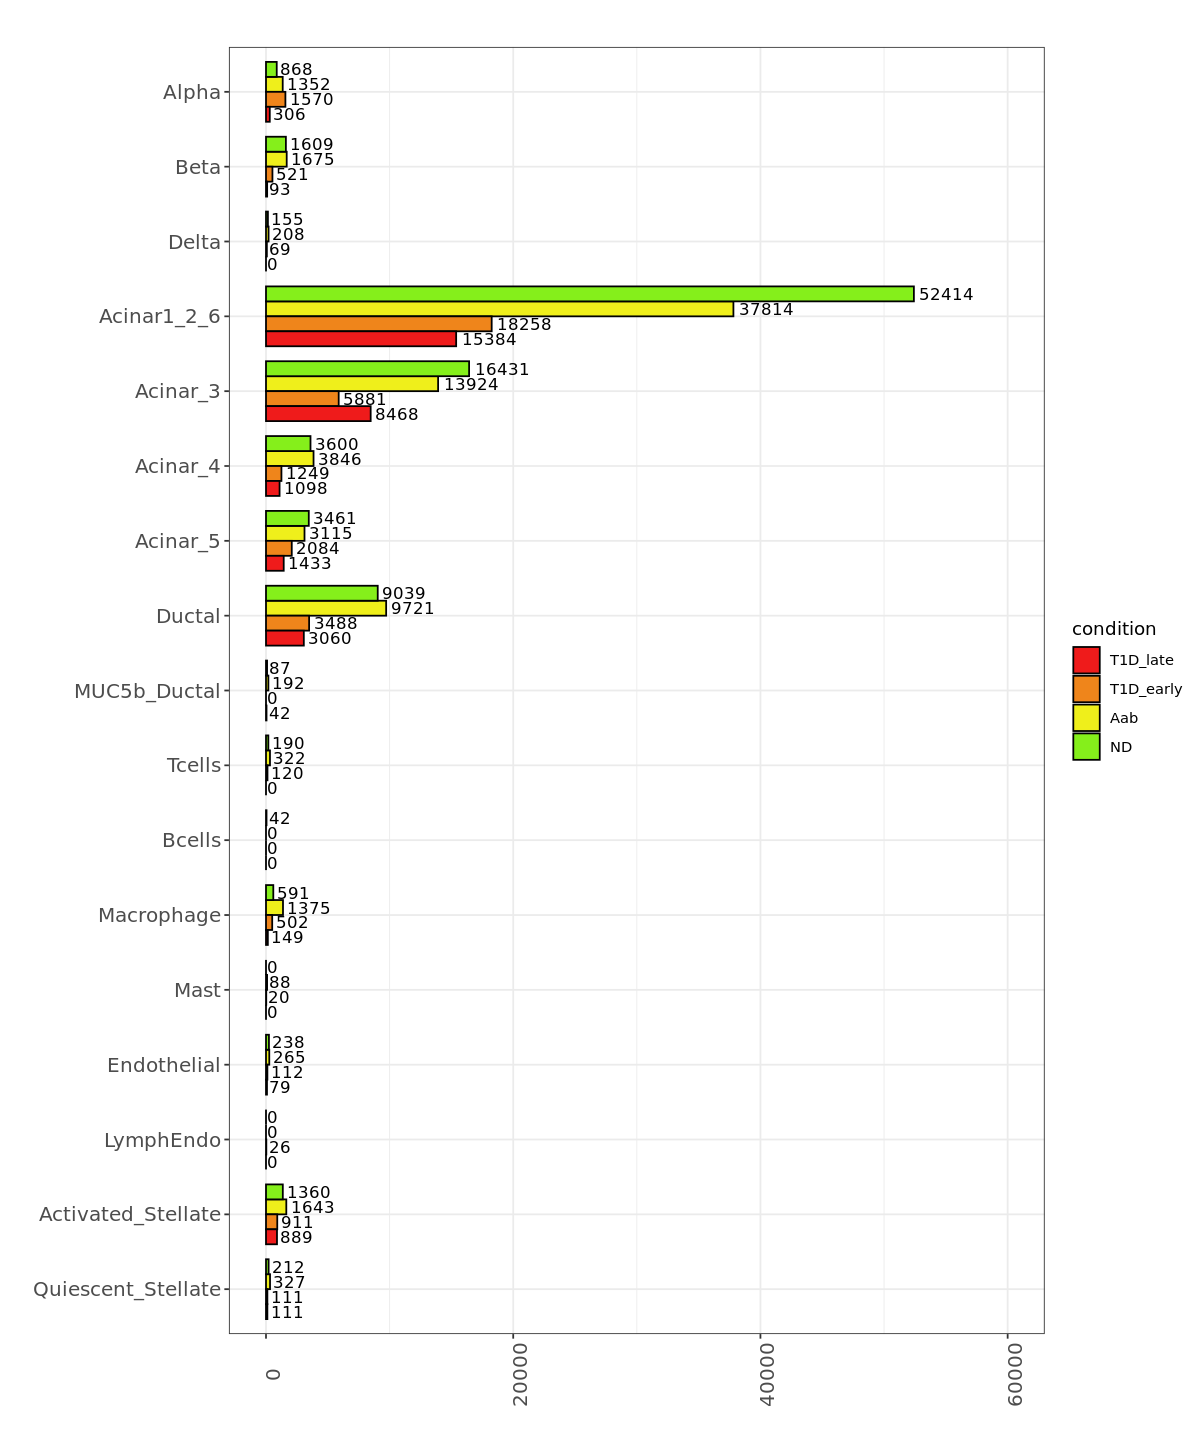

In [39]:
options(repr.plot.width=10, repr.plot.height=12)
ggplot(cell.pops, aes(x= cellpop, y = freq, fill = condition, label = freq)) +
       theme_bw () +
       geom_bar(stat="identity", colour="black", width = 0.8, position = position_dodge(width = 0.8), colour="black") +
       scale_fill_manual(values= colors.conditions)+
       labs(y= "", x = "", title = paste(""))+
       ylim(0, 60000)+
       theme(axis.text = element_text(size = 12), axis.title = element_text(size = 12, face = "bold"),
                  axis.text.x = element_text(angle = 90),
                             plot.title = element_text(size = 18, face = "bold", , hjust = 0.5)) +
coord_flip()+
geom_text(hjust = - 0.1, size = 3.5, position = position_dodge(width = 0.8)) # requires the labels aes

In [40]:
cell.pops = as.data.frame(table(seurat_object$celltype, seurat_object$condition))
colnames(cell.pops) = c("cellpop", "condition", "freq")

In [41]:
cellpop.presence = as.data.frame(table(cell.pops$cellpop, cell.pops$condition, cell.pops$freq > 0))
colnames(cellpop.presence) = c("cellpop", "condition", "presence","freq")
cellpop.presence$cellpop = factor(cellpop.presence$cellpop, levels = rev.cell.pop.order)
cellpop.presence$condition = factor(cellpop.presence$condition, levels = rev(condition.ls))
cellpop.presence = cellpop.presence[cellpop.presence$presence == TRUE,]
head(cellpop.presence)

,cellpop,condition,presence,freq
,<fct>,<fct>,<fct>,<int>
69,Acinar_3,Aab,TRUE,1
70,Acinar_4,Aab,TRUE,1
71,Acinar_5,Aab,TRUE,1
72,Acinar1_2_6,Aab,TRUE,1
73,Activated_Stellate,Aab,TRUE,1
74,Alpha,Aab,TRUE,1


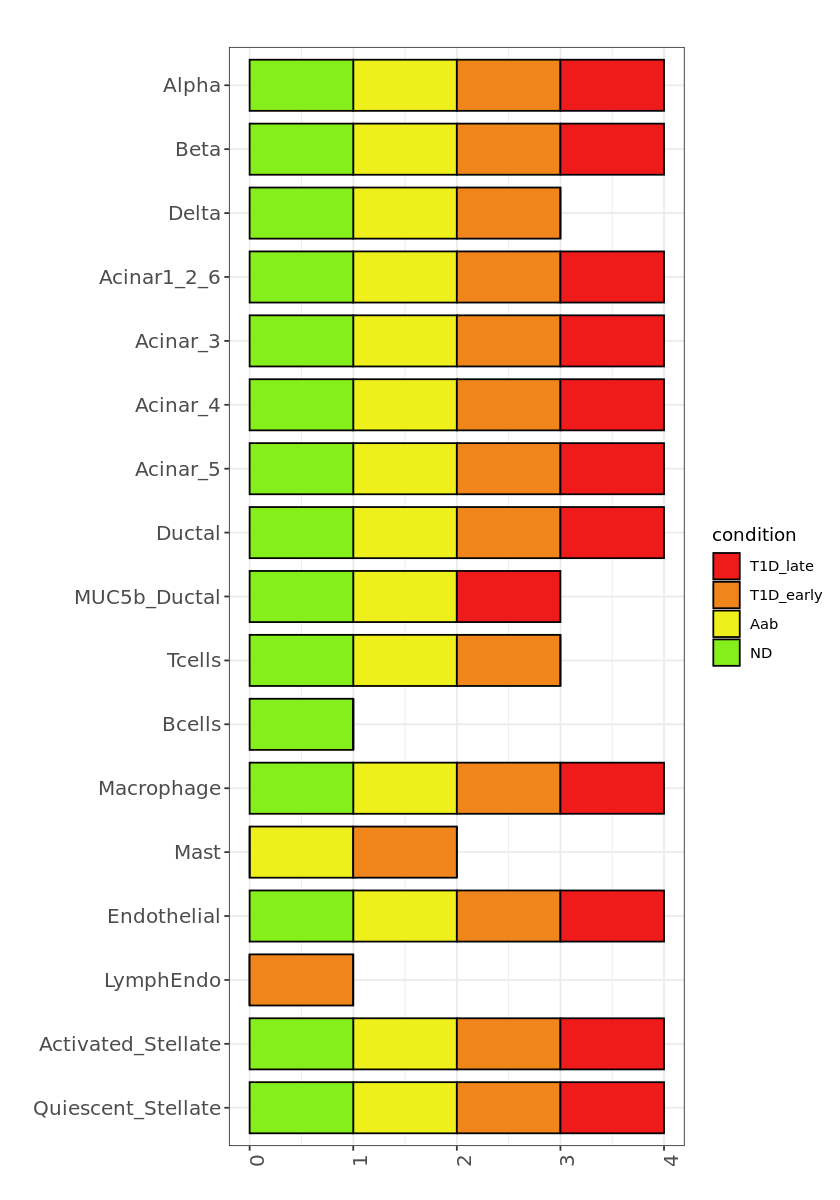

In [42]:
options(repr.plot.width=7, repr.plot.height=10)
ggplot(cellpop.presence, aes(x= cellpop, y = freq, fill = condition)) +
       theme_bw () +
       geom_bar(stat="identity", colour="black", width = 0.8) +
       scale_fill_manual(values= colors.conditions)+
       labs(y= "", x = "", title = paste(""))+
       theme(axis.text = element_text(size = 12), axis.title = element_text(size = 12, face = "bold"),
                  axis.text.x = element_text(angle = 90),
                             plot.title = element_text(size = 18, face = "bold", , hjust = 0.5)) +
coord_flip()

## By Sample

In [43]:
# Grab samples name

sample.conditions = data.frame(table(seurat_object$condition, seurat_object$samples))
colnames(sample.conditions) = c("condition", "sample", "freq")
sample.conditions = sample.conditions[sample.conditions$freq > 0,]

nd.samples = sample.conditions[sample.conditions$condition == condition.ls[1],]
nd.samples = nd.samples$sample

aab.samples =  sample.conditions[sample.conditions$condition == condition.ls[2],]
aab.samples = aab.samples$sample

etd.samples = sample.conditions[sample.conditions$condition == condition.ls[3],]
etd.samples = etd.samples$sample

ltd.samples = sample.conditions[sample.conditions$condition == condition.ls[4],]
ltd.samples = ltd.samples$sample

sample.order = c(nd.samples, aab.samples, etd.samples, ltd.samples)

rev.sample.order = c(rev(ltd.samples), rev(etd.samples), rev(aab.samples), rev(nd.samples))
length(nd.samples) + length(aab.samples) + length(etd.samples) + length(ltd.samples)

[1] 31

In [44]:
cell.pops = as.data.frame(table(seurat_object$celltype, seurat_object$samples, seurat_object$condition))
colnames(cell.pops) = c("cellpop", "sample", "condition","freq")

In [45]:
cellpop.presence = as.data.frame(table(cell.pops$cellpop, cell.pops$sample, cell.pops$condition, cell.pops$freq > 0))
colnames(cellpop.presence) = c("cellpop", "sample", "condition", "presence","freq")
cellpop.presence$cellpop = factor(cell.pops$cellpop, levels = rev.cell.pop.order)
cellpop.presence$sample = factor(cell.pops$sample, levels = rev.sample.order)
cellpop.presence$condition = factor(cellpop.presence$condition, levels = rev(condition.ls))
cellpop.presence = cellpop.presence[cellpop.presence$presence == TRUE,]
head(cellpop.presence)

,cellpop,sample,condition,presence,freq
,<fct>,<fct>,<fct>,<fct>,<int>
2109,Acinar_3,6197,Aab,TRUE,1
2110,Acinar_4,6197,Aab,TRUE,1
2111,Acinar_5,6197,Aab,TRUE,1
2112,Acinar1_2_6,6197,Aab,TRUE,1
2113,Activated_Stellate,6197,Aab,TRUE,1
2114,Alpha,6197,Aab,TRUE,1


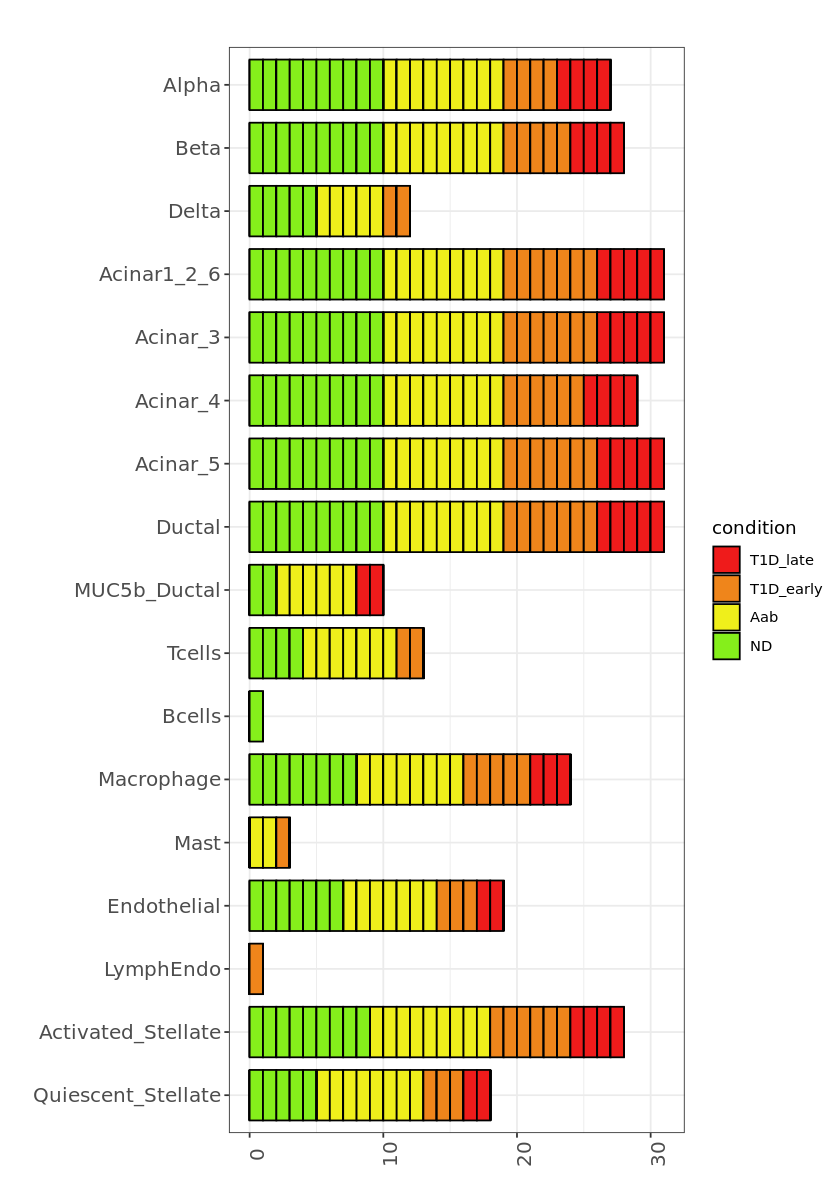

In [46]:
options(repr.plot.width=7, repr.plot.height=10)
ggplot(cellpop.presence, aes(x= cellpop, y = freq, fill = condition)) +
       theme_bw () +
       geom_bar(stat="identity", colour="black", width = 0.8) +
       scale_fill_manual(values= colors.conditions)+
       labs(y= "", x = "", title = paste(""))+
       theme(axis.text = element_text(size = 12), axis.title = element_text(size = 12, face = "bold"),
                  axis.text.x = element_text(angle = 90),
                             plot.title = element_text(size = 18, face = "bold", , hjust = 0.5)) +
coord_flip()

In [47]:
levels(factor(seurat_object$celltype))

[1] "Acinar_3"           "Acinar_4"           "Acinar_5"          
 [4] "Acinar1_2_6"        "Activated_Stellate" "Alpha"             
 [7] "Bcells"             "Beta"               "Delta"             
[10] "Ductal"             "Endothelial"        "LymphEndo"         
[13] "Macrophage"         "Mast"               "MUC5b_Ductal"      
[16] "Quiescent_Stellate" "Tcells"

In [48]:
## Remove cell popps we don't need
remove = c("LymphEndo", "Mast", "Bcells")
keep = cell.pop.order[!cell.pop.order %in% remove]

## Store fraction of samples with celltypes of interest

In [49]:
# If less than 2, then is 2

In [50]:
cellpop.sample.fraction = data.frame(table(cellpop.presence$cellpop, cellpop.presence$freq))
cellpop.sample.fraction = cellpop.sample.fraction[!cellpop.sample.fraction$Var1 %in% remove, ]
cellpop.sample.fraction = cellpop.sample.fraction[cellpop.sample.fraction$Var2 == 1,]
cellpop.sample.fraction = cellpop.sample.fraction[,c(1,3)]
colnames(cellpop.sample.fraction) = c("cellpop", "n.samples")
cellpop.sample.fraction$tresh_50pct = ceiling(cellpop.sample.fraction$n.samples/2)
cellpop.sample.fraction$tresh_25pct = ceiling(cellpop.sample.fraction$n.samples/4)
cellpop.sample.fraction$tresh_20pct = ceiling(cellpop.sample.fraction$n.samples/5)
cellpop.sample.fraction$tresh_10pct = ceiling(cellpop.sample.fraction$n.samples/10)
cellpop.sample.fraction$tresh_10pct[cellpop.sample.fraction$tresh_10pct < 2] = 2
cellpop.sample.fraction$cellpop = factor(cellpop.sample.fraction$cellpop, levels = cell.pop.order)

cellpop.sample.fraction

,cellpop,n.samples,tresh_50pct,tresh_25pct,tresh_20pct,tresh_10pct
,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
18,Quiescent_Stellate,18,9,5,4,2
19,Activated_Stellate,28,14,7,6,3
21,Endothelial,19,10,5,4,2
23,Macrophage,24,12,6,5,3
25,Tcells,13,7,4,3,2
26,MUC5b_Ductal,10,5,3,2,2
27,Ductal,31,16,8,7,4
28,Acinar_5,31,16,8,7,4
29,Acinar_4,29,15,8,6,3


In [51]:
write.table(cellpop.sample.fraction, paste(assets.dir, "cellpop.sample.fraction.txt", sep = ""), 
            sep = "\t", row.names = T, col.names = T)

## Save un-corrected RDS for cellchat

In [52]:
assay = "RNA.SCT"

In [53]:
# Create a new Seurat object with just the genes of interest
seurat.SM = GetAssayData(seurat_object, assay = assay, slot = "data") # Here u can choose the assay to subset
seurat.SM = seurat.SM[SM.ls, ]
seurat.SM = CreateSeuratObject(seurat.SM)
seurat.SM$celltype = seurat_object$celltype
seurat.SM = SetIdent(seurat.SM, value = seurat.SM$celltype)
seurat.SM$condition = seurat_object$condition
seurat.SM$samples = seurat_object$samples
seurat.SM <- subset(x = seurat.SM, subset = celltype %in% keep)

rna = GetAssayData(seurat.SM, slot = "data")
seurat.SM
levels(factor(seurat.SM$celltype))

An object of class Seurat 
857 features across 232022 samples within 1 assay 
Active assay: RNA (857 features, 0 variable features)

[1] "Acinar_3"           "Acinar_4"           "Acinar_5"          
 [4] "Acinar1_2_6"        "Activated_Stellate" "Alpha"             
 [7] "Beta"               "Delta"              "Ductal"            
[10] "Endothelial"        "Macrophage"         "MUC5b_Ductal"      
[13] "Quiescent_Stellate" "Tcells"

In [54]:
file = paste(assets.dir, Seurat.name, ".SM.RDS", sep = "")

In [55]:
saveRDS(seurat.SM, file = file)

# Create list of expressed genes

In [30]:
seurat.SM = readRDS(paste(assets.dir, Seurat.name, ".SM.RDS", sep = ""))
seurat.SM 

An object of class Seurat 
857 features across 232022 samples within 1 assay 
Active assay: RNA (857 features, 0 variable features)

In [31]:
assay = "RNA.SCT"

In [32]:
samples.ls = levels(factor(seurat.SM$samples))
samples.ls

[1] "6197" "6220" "6228" "6229" "6234" "6236" "6247" "6264" "6267" "6282"
[11] "6310" "6339" "6362" "6366" "6375" "6380" "6393" "6401" "6405" "6418"
[21] "6424" "6429" "6431" "6450" "6456" "6459" "6479" "6505" "6512" "6520"
[31] "6521"

In [ ]:
# Versione che prende SD su tutto dataset
log_print("Calculating expressors - Bysample V2")
gc(reset = TRUE)
means.mat = NULL
rna.ref = GetAssayData(seurat.SM, slot = "data")

for (g in seq_along(SM.ls)){
    # Setting looping variables
    gene = SM.ls[g]
    
    # take reference SD
    ref.sd = sd(rna.ref[gene,])/2
    message("Processing: ",gene)
    
        for (c in seq_along(samples.ls)){
            # Setting looping variables
            sample.use = samples.ls[[c]]
            seurat_object.use = subset(x = seurat.SM, subset = samples == sample.use)
            rna.use = GetAssayData(seurat_object.use, slot = "data")
            message("\t Sample: ", sample.use)
            cell.pop.ls = cell.pop.order[cell.pop.order %in% levels(factor(seurat_object.use$celltype))]

                for (i in seq_along(cell.pop.ls)){
                    CP = cell.pop.ls[i]
                    message("\t\t Celltype: ", CP)
                    # calculate mean and compare it with ref.sd
                    rna.CP.mean = mean(rna.use[gene, WhichCells(seurat_object.use, idents = CP)])
                    # Store results
                    means.mat$sample = rbind(means.mat$sample, sample.use)
                    means.mat$gene = rbind(means.mat$gene, gene)
                    means.mat$cellpop = rbind(means.mat$cellpop, CP)
                    means.mat$mean = rbind(means.mat$mean, rna.CP.mean)
                    means.mat$ref.SD = rbind(means.mat$ref.SD, ref.sd)
                    means.mat$expressor = rbind(means.mat$expressor, rna.CP.mean > ref.sd)
                }
        }
}

log_print("Done")

[1] "Calculating expressors - Bysample V2"


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4908059,262.2,9539175,509.5,4908059,262.2
Vcells,37235525,284.1,58239213,444.4,37235525,284.1


Processing: TGFB1

	 Sample: 6197

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Activated_Stellate

	 Sample: 6220

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Macrophage

		 Celltype: Activated_Stellate

	 Sample: 6228

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Sample: 6229

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endotheli

	 Sample: 6521

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

Processing: TGFB2

	 Sample: 6197

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Activated_Stellate

	 Sample: 6220

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Macrophage

		 Celltype: Activated_Stellate

	 Sample: 6228

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endotheli

	 Sample: 6520

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Sample: 6521

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

Processing: TGFB3

	 Sample: 6197

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Activated_Stellate

	 Sample: 6220

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype:

...

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

Processing: INHBA

	 Sample: 6197

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Activated_Stellate

	 Sample: 6220

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Macrophage

		 Celltype: Activated_Stellate

	 Sample: 6228

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quies

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Sample: 6521

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

Processing: INHBB

	 Sample: 6197

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Activated_Stellate

	 Sample: 6220

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Macrophage

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Sample: 6520

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Sample: 6521

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

Processing: INHBC

	 Sample: 6197

		 Celltype: Alpha

		 Celltype: Beta

		 Cell

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Sample: 6512

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Sample: 6520

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Sample: 6521

		 Celltype: Alpha

		 Celltype: Beta

		 Ce

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Sample: 6505

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Sample: 6512

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Sample: 6520

		 Celltype: Alpha

		 Celltype: Beta

	

In [ ]:
means.mat = as.data.frame(means.mat)
head(means.mat)
Expressors = means.mat[means.mat$expressor == TRUE,]
nrow(Expressors)

In [ ]:
write.table(means.mat, paste(assets.dir, "corrected.means.mat.bysampleV2.txt", sep = ""), 
            sep = "\t", row.names = T, col.names = T, quote = FALSE)

# Decide on subset

## By sample - only Ligands

In [84]:
means.mat.summary = read.table(paste(assets.dir, "corrected.means.mat.bysampleV2.txt", sep = ""))

In [85]:
# count ligands per celltype
means.mat.summary = means.mat.summary[means.mat.summary$expressor == TRUE,]
means.mat.summary = merge(means.mat.summary, SM.ls.df.GDB, by = "gene", all.x = TRUE)
means.mat.summary = means.mat.summary[!means.mat.summary$Type == "Receptor", ]
means.mat.summary = means.mat.summary[!means.mat.summary$Type == "Both", ]
message("Check that Receptors are not showing up :")
levels(factor(means.mat.summary$Type))

Check that Receptors are not showing up :



[1] "Ligand"

In [86]:
means.mat.summary = data.frame(table(means.mat.summary$cellpop, means.mat.summary$gene))
colnames(means.mat.summary) = c("cellpop", "gene", "Frequency")
means.mat.summary$cellpop = factor(means.mat.summary$cellpop, levels = rev.cell.pop.order)


In [87]:
markers = c("INS", "GCG", "SST", "PRSS2", "TNF", "GRN", "SPP1", "OPN")
#markers = c("INSR", "GCGR", "SSTR", "PARD3", "SORT1", "TNFRSF1A", "TNFRSF1B")
markers.data = means.mat.summary[means.mat.summary$gene %in% markers, ]
markers.data = markers.data[markers.data$Frequency != 0, ]
markers.data$gene = factor(markers.data$gene, levels = markers)

Warning message:
“Duplicated aesthetics after name standardisation: colour”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


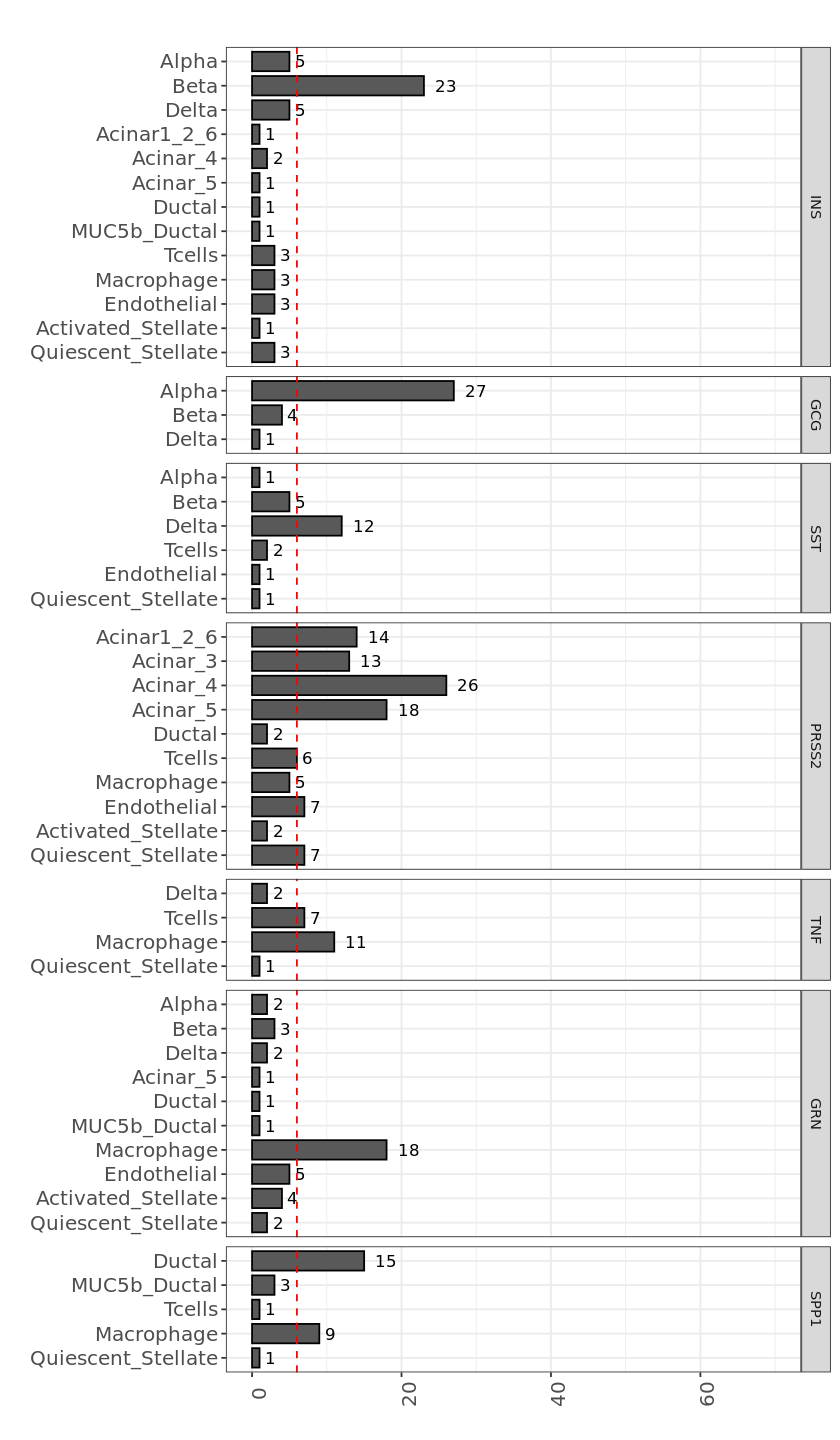

In [88]:
options(repr.plot.width=7, repr.plot.height=12)
ggplot(markers.data, aes(x= cellpop, y = Frequency, group = cellpop, label = Frequency)) +
       theme_bw () +
       geom_bar(stat="identity", colour="black", width = 0.8, 
                position = position_dodge(width = 0.8), colour="black") +
       labs(y= "", x = "", title = paste(""))+
       ylim(0,70)+
       theme(axis.text = element_text(size = 12), axis.title = element_text(size = 12, face = "bold"),
                  axis.text.x = element_text(angle = 90),
                             plot.title = element_text(size = 18, face = "bold", , hjust = 0.5)) +
coord_flip()+
geom_text(hjust = - 0.5, size = 3.5, position = position_dodge(width = 0.8)) +
geom_hline(yintercept = 6, color="red", linetype="dashed", size=0.5)+
facet_grid(gene ~. , scales = "free_y", space = "free_y")

In [89]:
# If we would put a threshold that would be higher than 6 samples
## This would avoid hormone cross-contamination

In [90]:
# Treshold plot
Freq.tresh = 6

In [91]:
threshold.plot = as.data.frame(table(means.mat.summary$cellpop, means.mat.summary$Frequency > Freq.tresh))
colnames(threshold.plot) = c("cellpop", "Frequency.conditions", "Frequency.aggregated")
threshold.plot$cellpop = factor(threshold.plot$cellpop, levels = rev.cell.pop.order)
## remove the 0 frequency.condition
threshold.plot = threshold.plot[!threshold.plot$Frequency.conditions == 0, ]
threshold.plot = threshold.plot[threshold.plot$Frequency.conditions == TRUE, ]
#threshold.plot$Frequency.conditions = factor(threshold.plot$Frequency.conditions, levels = rev(c("1","2","3","4")))

Warning message:
“Duplicated aesthetics after name standardisation: colour”


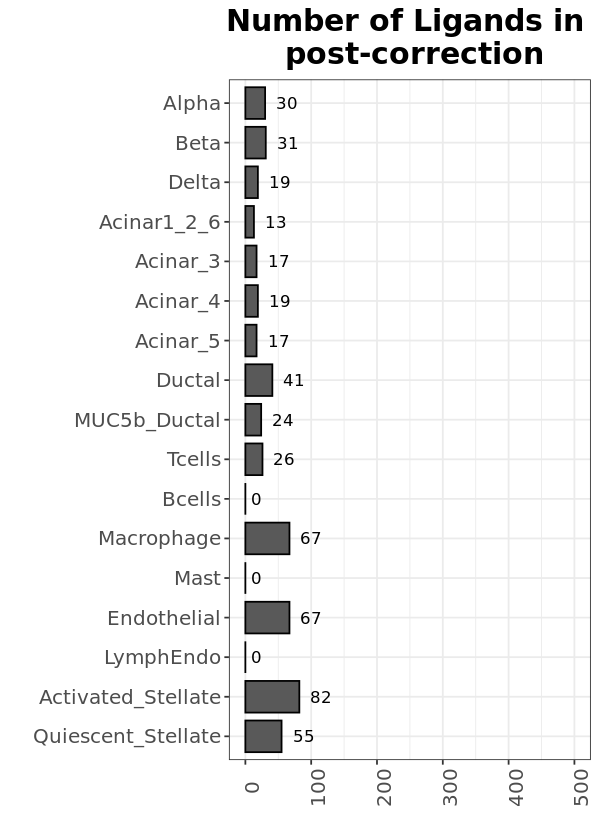

In [92]:
options(repr.plot.width=5, repr.plot.height=7)
ggplot(threshold.plot, aes(x= cellpop, y = Frequency.aggregated, label = Frequency.aggregated)) +
       theme_bw () +
       geom_bar(stat="identity", colour="black", width = 0.8, 
                position = position_dodge(width = 0.8), colour="black") +
       labs(y= "", x = "", title = paste("Number of Ligands in \n post-correction"))+
       ylim(0,500)+
       theme(axis.text = element_text(size = 12), axis.title = element_text(size = 12, face = "bold"),
                  axis.text.x = element_text(angle = 90),
                             plot.title = element_text(size = 18, face = "bold", , hjust = 0.5)) +
coord_flip()+
geom_text(hjust = - 0.5, size = 3.5, position = position_dodge(width = 0.8)) # requires the labels aes

In [93]:
# Save list of expressors/ligand
means.mat.summary.l = means.mat.summary[means.mat.summary$Frequency > Freq.tresh,]
head(means.mat.summary.l)

,cellpop,gene,Frequency
,<fct>,<fct>,<int>
7,Beta,ADCYAP1,23
19,Activated_Stellate,ADGRE5,11
25,Macrophage,ADGRE5,19
27,Quiescent_Stellate,ADGRE5,8
28,Tcells,ADGRE5,13
47,Activated_Stellate,ADM,19


## By sample fraction

In [94]:
means.mat.summary.sample.fraction = merge(means.mat.summary, cellpop.sample.fraction, by = "cellpop")
#means.mat.summary.sample.fraction$expr.50pt = means.mat.summary.sample.fraction$Frequency > means.mat.summary.sample.fraction$tresh_50pct
#means.mat.summary.sample.fraction$expr.25pt = means.mat.summary.sample.fraction$Frequency >= means.mat.summary.sample.fraction$tresh_25pct

test = means.mat.summary.sample.fraction[means.mat.summary.sample.fraction$gene == "INS", ]

message("> PCT50")
test$cellpop[test$Frequency >= test$tresh_50pct]
message(">= PCT25")
test$cellpop[test$Frequency >= test$tresh_25pct]
message(">= PCT20")
test$cellpop[test$Frequency >= test$tresh_20pct]
message(">= PCT10")
test$cellpop[test$Frequency >= test$tresh_10pct]

> PCT50



[1] Beta
17 Levels: Quiescent_Stellate Activated_Stellate LymphEndo Endothelial ... Alpha

>= PCT25



[1] Beta  Delta
17 Levels: Quiescent_Stellate Activated_Stellate LymphEndo Endothelial ... Alpha

>= PCT20



[1] Beta   Delta  Tcells
17 Levels: Quiescent_Stellate Activated_Stellate LymphEndo Endothelial ... Alpha

>= PCT10



[1] Alpha              Beta               Delta              Endothelial       
[5] Macrophage         Quiescent_Stellate Tcells            
17 Levels: Quiescent_Stellate Activated_Stellate LymphEndo Endothelial ... Alpha

In [95]:
#I am choosing 10% because I will anyways blacklist

In [96]:
threshold.plot = as.data.frame(table(means.mat.summary.sample.fraction$cellpop, 
        means.mat.summary.sample.fraction$Frequency >= means.mat.summary.sample.fraction$tresh_10pct))
colnames(threshold.plot) = c("cellpop", "Frequency.conditions", "Frequency.aggregated")
threshold.plot$cellpop = factor(threshold.plot$cellpop, levels = rev.cell.pop.order)
## remove the 0 frequency.condition
threshold.plot = threshold.plot[!threshold.plot$Frequency.conditions == 0, ]
threshold.plot = threshold.plot[threshold.plot$Frequency.conditions == TRUE, ]
#threshold.plot$Frequency.conditions = factor(threshold.plot$Frequency.conditions, levels = rev(c("1","2","3","4")))

Warning message:
“Duplicated aesthetics after name standardisation: colour”


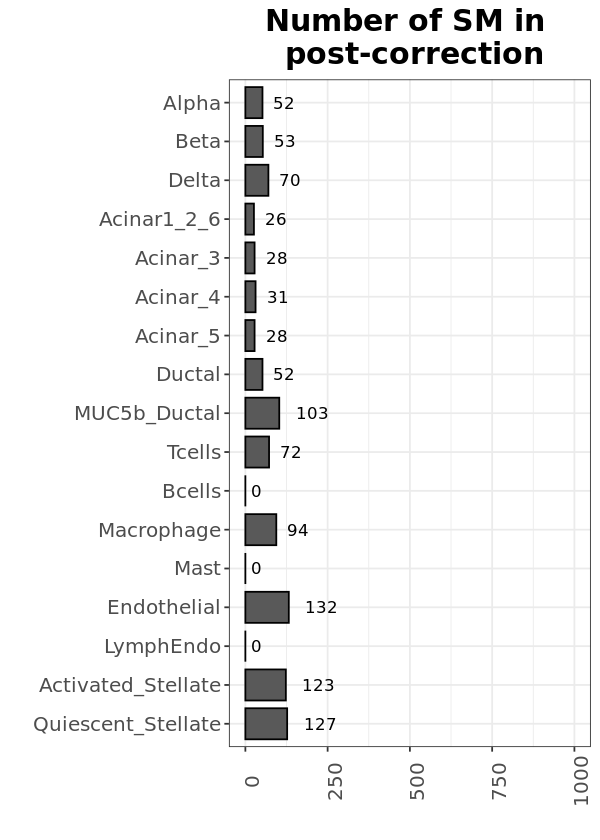

In [97]:
options(repr.plot.width=5, repr.plot.height=7)
ggplot(threshold.plot, aes(x= cellpop, y = Frequency.aggregated, label = Frequency.aggregated)) +
       theme_bw () +
       geom_bar(stat="identity", colour="black", width = 0.8, 
                position = position_dodge(width = 0.8), colour="black") +
       labs(y= "", x = "", title = paste("Number of SM in \n post-correction"))+
       ylim(0,1000)+
       theme(axis.text = element_text(size = 12), axis.title = element_text(size = 12, face = "bold"),
                  axis.text.x = element_text(angle = 90),
                             plot.title = element_text(size = 18, face = "bold", , hjust = 0.5)) +
coord_flip()+
geom_text(hjust = - 0.5, size = 3.5, position = position_dodge(width = 0.8)) # requires the labels aes

In [98]:
# Save list of expressors/ligand
means.mat.summary.l = means.mat.summary.sample.fraction[means.mat.summary.sample.fraction$Frequency >= means.mat.summary.sample.fraction$tresh_10pct,]
expressors = means.mat.summary.l[,c(1,2,3)]
head(expressors)

,cellpop,gene,Frequency
,<fct>,<fct>,<int>
18,Acinar_3,GDF15,5
48,Acinar_3,ANGPTL4,12
77,Acinar_3,SEMA5A,4
96,Acinar_3,KITLG,12
118,Acinar_3,APP,16
132,Acinar_3,AREG,4


In [99]:
nrow(expressors[expressors$cellpop == "Beta",])
nrow(expressors[expressors$cellpop == "Macrophage",])

[1] 53

[1] 94

In [100]:
# Yes, all good

In [101]:
# Print out expressors
write.table(expressors, paste(assets.dir, "expressors.bysample.txt", sep = ""), 
            sep = "\t", row.names = T, col.names = T)

# Correct Seurat object

In [102]:
# FILTERING ONLY LIGANDS

In [103]:
# Load expressors
expressors = read.table(paste(assets.dir, "expressors.bysample.txt", sep = ""),
              sep = "\t", stringsAsFactors = F, header = T)
head(expressors, n = 2)

,cellpop,gene,Frequency
,<chr>,<chr>,<int>
18,Acinar_3,GDF15,5
48,Acinar_3,ANGPTL4,12


In [104]:
# Selecet assay
assay = "RNA.SCT"

In [105]:
# Create a new Seurat object with just the genes of interest
seurat.SM = GetAssayData(seurat_object, assay = assay, slot = "data") # Here u can choose the assay to subset
seurat.SM = seurat.SM[SM.ls, ]
seurat.SM = CreateSeuratObject(seurat.SM)
seurat.SM$celltype = seurat_object$celltype
seurat.SM = SetIdent(seurat.SM, value = seurat.SM$celltype)
seurat.SM$condition = seurat_object$condition
seurat.SM$samples = seurat_object$samples
seurat.SM <- subset(x = seurat.SM, subset = celltype %in% keep)
rna = GetAssayData(seurat.SM, slot = "data")
seurat.SM

An object of class Seurat 
857 features across 232022 samples within 1 assay 
Active assay: RNA (857 features, 0 variable features)

In [106]:
# Filtering just ligands out
log_print("Subsetting RNA.SCT matrix")
rna.corrected = GetAssayData(seurat.SM, slot = "data")
cell.pop.ls = levels(factor(seurat.SM$celltype))
gc(reset = TRUE)

for (i in seq_along(cell.pop.ls)){
    CP = cell.pop.ls[i]
    message("\t processing: ", CP)
    expressing.gene.ls = expressors$gene[expressors$cellpop == CP]
    not.expressing.gene.ls = ligands.ls[!ligands.ls %in% expressing.gene.ls]
    rna.corrected[not.expressing.gene.ls, WhichCells(seurat.SM, idents = CP)] = 0
}   
log_print("Done")

[1] "Subsetting RNA.SCT matrix"


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,5574959,297.8,12496252,667.4,5574959,297.8
Vcells,4234822488,32309.2,9153920696,69838.9,4234822488,32309.2


	 processing: Acinar_3

	 processing: Acinar_4

	 processing: Acinar_5

	 processing: Acinar1_2_6

	 processing: Activated_Stellate

	 processing: Alpha

	 processing: Beta

	 processing: Delta

	 processing: Ductal

	 processing: Endothelial

	 processing: Macrophage

	 processing: MUC5b_Ductal

	 processing: Quiescent_Stellate

	 processing: Tcells



[1] "Done"


In [107]:
# Save RDS
        # Create new object using the corrected matrix
        seurat.SM.corrected = CreateSeuratObject(rna.corrected)
        seurat.SM.corrected = SetIdent(seurat.SM.corrected, value = seurat.SM$celltype)
        seurat.SM.corrected$condition = seurat.SM$condition
        seurat.SM.corrected$samples = seurat.SM$samples
        seurat.SM.corrected$celltype = seurat.SM$celltype
        file = paste(assets.dir, Seurat.name, ".SM.Lpct10.rds",sep = "")
        saveRDS(seurat.SM.corrected, file = file)

## U can use this RDS for cellchat and below

In [116]:
# Quick check that it was corrected
mean(rna.corrected["INS", WhichCells(seurat.SM, idents = "Beta")])
mean(rna.corrected["PRSS1", WhichCells(seurat.SM, idents = "Beta")])

[1] 2.132212

[1] 0

# Re-calculate averages for SM expression analysis

## Whole DB

In [ ]:
# I have to re-calculate the mean because I have the means by-sample and I want to use the overall means 

In [ ]:
file
Seurat.use = readRDS(file)
rna.use = GetAssayData(Seurat.use, slot = "data")

In [ ]:
log_print("Grabbing averages")
gc(reset = TRUE)
means.mat <- NULL

for (g in seq_along(SM.ls)){
    gene = SM.ls[g]
    message(gene)
        for (i in seq_along(cell.pop.ls)){
            CP = cell.pop.ls[i]
            message("\t processing: ", CP)
                # calculate mean and compare it with ref.sd
                rna.CP.mean = mean(rna.use[gene, WhichCells(Seurat.use, idents = CP)])
                # Store results
                means.mat$gene = rbind(means.mat$gene, gene)
                means.mat$cellpop = rbind(means.mat$cellpop, CP)
                means.mat$mean = rbind(means.mat$mean, rna.CP.mean)
        }
}
means.mat = as.data.frame(means.mat)
head(means.mat)

write.table(means.mat, paste(assets.dir, "wholedb.corrected.means.mat.bysampleV2.post-correction.txt", sep = ""), 
            sep = "\t", row.names = T, col.names = T, quote = FALSE)
log_print("Done")

## By condition

In [137]:
file
Seurat.use = readRDS(file)
rna.use = GetAssayData(Seurat.use, slot = "data")

[1] "/nfs/lab/projects/CellCrosstalk/npod.pancreas/Final/Assets/20230518_RNA_FiltMin20exceptBetaLate_CellChat_nPODids.SCT.rds.SM.Lpct10.rds"

In [138]:
# I have to re-calculate the mean because I have the means by-sample and I want to use the overall means 

In [141]:
condition.ls <- c("ND", "Aab", "T1D_early", "T1D_late")

In [142]:
seurat_object.ls = list()

log_print("Splitting conditions")
for (i in seq_along(condition.ls)){
    gc(reset = TRUE)
    condition.use = condition.ls[i]
    log_print(condition.use)
    seurat_object.ls[[i]] <- subset(x = Seurat.use, subset = condition == condition.use)
}

[1] "Splitting conditions"
[1] "ND"
[1] "Aab"
[1] "T1D_early"
[1] "T1D_late"


In [ ]:
log_print("Grabbing corrected means - by condition")
gc(reset = TRUE)
means.mat = NULL

for (g in seq_along(SM.ls)){
    # Setting looping variables
    gene = SM.ls[g]
    message("Processing: ",gene)
    
        for (c in seq_along(condition.ls)){
            # Setting looping variables
            seurat_object.use = seurat_object.ls[[c]]
            rna.use = GetAssayData(seurat_object.use, slot = "data")
            condition.use = condition.ls[[c]]
            cell.pop.ls = cell.pop.order[cell.pop.order %in% levels(factor(seurat_object.use$celltype))]
            message("\t Condition: ", condition.use)

                for (i in seq_along(cell.pop.ls)){
                    CP = cell.pop.ls[i]
                    message("\t\t Celltype: ", CP)
                    # calculate mean and compare it with ref.sd
                    rna.CP.mean = mean(rna.use[gene, WhichCells(seurat_object.use, idents = CP)])
                    # Store results
                    means.mat$condition = rbind(means.mat$condition, condition.use)
                    means.mat$gene = rbind(means.mat$gene, gene)
                    means.mat$cellpop = rbind(means.mat$cellpop, CP)
                    means.mat$mean = rbind(means.mat$mean, rna.CP.mean)
                }
        }
}

means.mat = as.data.frame(means.mat)

write.table(means.mat, paste(assets.dir, "by.condition.corrected.means.mat.bysampleV2.SM.post-correction.txt", sep = ""), 
            sep = "\t", row.names = T, col.names = T, quote = FALSE)

log_print("Done")

[1] "Grabbing corrected means - by condition"


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,5869037,313.5,12496252,667.4,5869037,313.5
Vcells,4262438835,32519.9,9153920696,69838.9,4262438835,32519.9


Processing: TGFB1

	 Condition: ND

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Condition: Aab

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Condition: T1D_early

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothel

		 Celltype: MUC5b_Ductal

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

Processing: GDF6

	 Condition: ND

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Condition: Aab

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Condition: T1D_early

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: A

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

Processing: BMP8B

	 Condition: ND

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Condition: Aab

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate



...

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Condition: T1D_early

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Condition: T1D_late

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

Processing: LRP1

	 Condition: ND

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: M

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Condition: T1D_early

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Condition: T1D_late

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

Processing: BDKRB1

	 Condition: ND

		 Celltype: Alpha

		 Celltype: Beta

		 Celltyp

		 Celltype: Quiescent_Stellate

	 Condition: Aab

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Condition: T1D_early

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Condition: T1D_late

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Act

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Condition: Aab

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Condition: T1D_early

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Condition: T1D_late

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Cellt

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Condition: Aab

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: MUC5b_Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Condition: T1D_early

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Delta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

## By Sample

In [160]:
file
Seurat.use = readRDS(file)
rna.use = GetAssayData(Seurat.use, slot = "data")

[1] "/nfs/lab/projects/CellCrosstalk/npod.pancreas/Final/Assets/20230518_RNA_FiltMin20exceptBetaLate_CellChat_nPODids.SCT.rds.SM.Lpct10.rds"

In [161]:
assay = "RNA.SCT"

In [162]:
samples.ls = levels(factor(Seurat.use$samples))

In [163]:
levels(factor(Seurat.use$condition))

[1] "Aab"       "ND"        "T1D_early" "T1D_late"

In [ ]:
log_print("Calculating expressors - Bysample")
gc(reset = TRUE)
means.mat = NULL
rna.ref = GetAssayData(Seurat.use, slot = "data")

for (g in seq_along(SM.ls)){
    # Setting looping variables
    gene = SM.ls[g]
    print(gene)
        for (c in seq_along(samples.ls)){
            # Setting looping variables
            sample.use = samples.ls[[c]]
            seurat_object.use = subset(x = Seurat.use, subset = samples == sample.use)
            condition.use = levels(factor(seurat_object.use$condition))
            rna.use = GetAssayData(seurat_object.use, slot = "data")
            message("\t Sample: ", sample.use)
            cell.pop.ls = cell.pop.order[cell.pop.order %in% levels(factor(seurat_object.use$celltype))]
                for (i in seq_along(cell.pop.ls)){
                    CP = cell.pop.ls[i]
                    message("\t\t Celltype: ", CP)
                    # calculate mean and compare it with ref.sd
                    rna.CP.mean = mean(rna.use[gene, WhichCells(seurat_object.use, idents = CP)])
                    # Store results
                    means.mat$sample = rbind(means.mat$sample, sample.use)
                    means.mat$condition = rbind(means.mat$condition, condition.use)
                    means.mat$gene = rbind(means.mat$gene, gene)
                    means.mat$cellpop = rbind(means.mat$cellpop, CP)
                    means.mat$mean = rbind(means.mat$mean, rna.CP.mean)
                }
        }
}

log_print("Done")

[1] "Calculating expressors - Bysample"


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,5585482,298.3,12496252,667.4,5585482,298.3
Vcells,4258369085,32488.8,9153920696,69838.9,4258369085,32488.8


[1] "TGFB1"


	 Sample: 6197

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Activated_Stellate

	 Sample: 6220

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Macrophage

		 Celltype: Activated_Stellate

	 Sample: 6228

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Sample: 6229

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Ac

	 Sample: 6521

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate



...

[1] "WNT9B"


	 Sample: 6197

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Activated_Stellate

	 Sample: 6220

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Macrophage

		 Celltype: Activated_Stellate

	 Sample: 6228

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Sample: 6229

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Ac

	 Sample: 6521

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate



[1] "WNT5A"


	 Sample: 6197

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Activated_Stellate

	 Sample: 6220

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Macrophage

		 Celltype: Activated_Stellate

	 Sample: 6228

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Activated_Stellate

		 Celltype: Quiescent_Stellate

	 Sample: 6229

		 Celltype: Alpha

		 Celltype: Beta

		 Celltype: Acinar1_2_6

		 Celltype: Acinar_3

		 Celltype: Acinar_4

		 Celltype: Acinar_5

		 Celltype: Ductal

		 Celltype: Tcells

		 Celltype: Macrophage

		 Celltype: Endothelial

		 Celltype: Ac

In [ ]:
levels(factor(seurat_object.use$samples))

In [ ]:
means.mat = as.data.frame(means.mat)
head(means.mat)
nrow(means.mat)

In [ ]:
write.table(means.mat, paste(assets.dir, "bySample.corrected.means.mat.bysampleV2.post-correction.txt", sep = ""), 
            sep = "\t", row.names = T, col.names = T, quote = FALSE)